In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
df_train = pd.read_csv('/content/drive/MyDrive/archive/fraudTrain_cleaned.csv')

print(f"Dataset shape: {df_train.shape}")

Dataset shape: (1296675, 29)


## Why Gradient Boosting?

### Purpose
Predict how much a user will spend **next month** based on their past spending patterns.


### Why Gradient Boosting?

| Reason | Explanation |
|--------|-------------|
| **Works with many features** | Can use 30+ features effectively |
| **Robust to outliers** | Won't be thrown off by one big purchase |
| **Feature importance** | Tells us which features matter most |

### How It Works
1. Builds many small decision trees sequentially
2. Each tree corrects the errors of the previous one
3. Combines all trees for final prediction

Our goal is to predict a user's next month's spending based on their past spending patterns

Feature Engineering

In [4]:
# Convert datetime columns
df_train['datetime'] = pd.to_datetime(df_train['trans_date_trans_time'])
df_train['year_month'] = df_train['datetime'].dt.to_period('M')

# Convert dob to age
df_train['dob'] = pd.to_datetime(df_train['dob'])
df_train['age'] = (pd.to_datetime('2019-06-01') - df_train['dob']).dt.days // 365

# Encode gender (1 = Male, 0 = Female)
df_train['gender_encoded'] = (df_train['gender'] == 'M').astype(int)

print(f"Date range: {df_train['year_month'].min()} to {df_train['year_month'].max()}")
print(f"Age range: {df_train['age'].min()} - {df_train['age'].max()}")

Date range: 2019-01 to 2020-06
Age range: 14 - 94


Create Monthly User Data

In [5]:
# Monthly spending stats per user
monthly_spending = df_train.groupby(['cc_num', 'year_month']).agg(
    total_spent=('amt', 'sum'),
    avg_transaction=('amt', 'mean'),
    num_transactions=('amt', 'count'),
    std_transaction=('amt', 'std'),
    max_transaction=('amt', 'max'),
    min_transaction=('amt', 'min'),
    unique_categories=('category', 'nunique'),
    age=('age', 'first'),
    gender=('gender_encoded', 'first'),
    weekend_transactions=('is_weekend', 'sum')
).reset_index()

monthly_spending['std_transaction'] = monthly_spending['std_transaction'].fillna(0)
monthly_spending['weekend_pct'] = monthly_spending['weekend_transactions'] / monthly_spending['num_transactions']

print(f"Monthly spending shape: {monthly_spending.shape}")

Monthly spending shape: (16422, 13)


In [6]:
# Monthly spending BY CATEGORY per user
category_monthly = df_train.groupby(['cc_num', 'year_month', 'category'])['amt'].sum().unstack(fill_value=0)
category_monthly = category_monthly.reset_index()

monthly_spending = monthly_spending.merge(category_monthly, on=['cc_num', 'year_month'], how='left')

print(f"Shape with categories: {monthly_spending.shape}")
print(f"Category columns added: {category_monthly.columns.tolist()[2:]}")

Shape with categories: (16422, 27)
Category columns added: ['entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos', 'health_fitness', 'home', 'kids_pets', 'misc_net', 'misc_pos', 'personal_care', 'shopping_net', 'shopping_pos', 'travel']


Create Target Variable

In [7]:
# Sort by user and month
monthly_spending = monthly_spending.sort_values(['cc_num', 'year_month']).reset_index(drop=True)

# TARGET: Next month's total spending
monthly_spending['next_month_spent'] = monthly_spending.groupby('cc_num')['total_spent'].shift(-1)

# LAG FEATURES
monthly_spending['prev_total_spent'] = monthly_spending.groupby('cc_num')['total_spent'].shift(1)
monthly_spending['prev_2_total_spent'] = monthly_spending.groupby('cc_num')['total_spent'].shift(2)
monthly_spending['prev_3_total_spent'] = monthly_spending.groupby('cc_num')['total_spent'].shift(3)
monthly_spending['prev_num_transactions'] = monthly_spending.groupby('cc_num')['num_transactions'].shift(1)

# ROLLING AVERAGES
monthly_spending['rolling_2m_avg'] = monthly_spending.groupby('cc_num')['total_spent'].transform(
    lambda x: x.shift(1).rolling(window=2, min_periods=1).mean()
)
monthly_spending['rolling_3m_avg'] = monthly_spending.groupby('cc_num')['total_spent'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean()
)

monthly_spending['spending_change'] = monthly_spending['total_spent'] - monthly_spending['prev_total_spent']
monthly_spending['spending_change_pct'] = (monthly_spending['spending_change'] / monthly_spending['prev_total_spent']).replace([np.inf, -np.inf], 0).fillna(0)

monthly_spending['month_num'] = monthly_spending['year_month'].dt.month

print("All features created!")
print(f"Total columns: {len(monthly_spending.columns)}")

All features created!
Total columns: 37


Prepare Data for training

In [8]:
df_model = monthly_spending.dropna(subset=['next_month_spent', 'prev_total_spent', 'prev_2_total_spent', 'prev_3_total_spent'])

print(f"Rows for modeling: {len(df_model)}")

Rows for modeling: 12712


In [9]:
# Check which columns exist in df_model
print("Columns in df_model:")
print(df_model.columns.tolist())

Columns in df_model:
['cc_num', 'year_month', 'total_spent', 'avg_transaction', 'num_transactions', 'std_transaction', 'max_transaction', 'min_transaction', 'unique_categories', 'age', 'gender', 'weekend_transactions', 'weekend_pct', 'entertainment', 'food_dining', 'gas_transport', 'grocery_net', 'grocery_pos', 'health_fitness', 'home', 'kids_pets', 'misc_net', 'misc_pos', 'personal_care', 'shopping_net', 'shopping_pos', 'travel', 'next_month_spent', 'prev_total_spent', 'prev_2_total_spent', 'prev_3_total_spent', 'prev_num_transactions', 'rolling_2m_avg', 'rolling_3m_avg', 'spending_change', 'spending_change_pct', 'month_num']


In [10]:
# Define features
feature_cols = [
    # Basic spending stats
    'total_spent', 'avg_transaction', 'num_transactions',
    'std_transaction', 'max_transaction', 'min_transaction',
    'unique_categories', 'age', 'gender', 'weekend_pct',

    # Category breakdown
    'entertainment', 'food_dining', 'gas_transport', 'grocery_net',
    'grocery_pos', 'health_fitness', 'home', 'kids_pets',
    'misc_net', 'misc_pos', 'personal_care', 'shopping_net',
    'shopping_pos', 'travel',

    # Lag features
    'prev_total_spent', 'prev_2_total_spent', 'prev_3_total_spent',
    'prev_num_transactions', 'rolling_2m_avg', 'rolling_3m_avg',
    'spending_change', 'spending_change_pct', 'month_num'
]

X = df_model[feature_cols]
y = df_model['next_month_spent']

print(f"Features: {len(feature_cols)}")
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

Features: 33
X shape: (12712, 33)
y shape: (12712,)


In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Train set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Train set: 10169 rows
Test set: 2543 rows


Gradient Boosting Model

In [12]:
# Train Gradient Boosting Regressor
gb_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)

gb_model.fit(X_train, y_train)
print("Gradient Boosting model trained!")

Gradient Boosting model trained!


Make Predictions

In [13]:
y_pred_train = gb_model.predict(X_train)
y_pred_test = gb_model.predict(X_test)

In [14]:
# Calculate metrics
train_r2 = r2_score(y_train, y_pred_train)
train_mae = mean_absolute_error(y_train, y_pred_train)

test_r2 = r2_score(y_test, y_pred_test)
test_mae = mean_absolute_error(y_test, y_pred_test)
test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))

In [15]:
print("GRADIENT BOOSTING EVALUATION")
print("="*50)

print(f"\nTraining Performance:")
print(f"  R²:  {train_r2:.4f}")
print(f"  MAE: ${train_mae:.2f}")

print(f"\nTest Performance:")
print(f"  R²:   {test_r2:.4f}")
print(f"  MAE:  ${test_mae:.2f}")
print(f"  RMSE: ${test_rmse:.2f}")

GRADIENT BOOSTING EVALUATION

Training Performance:
  R²:  0.8467
  MAE: $1116.39

Test Performance:
  R²:   0.7706
  MAE:  $1295.31
  RMSE: $1987.09


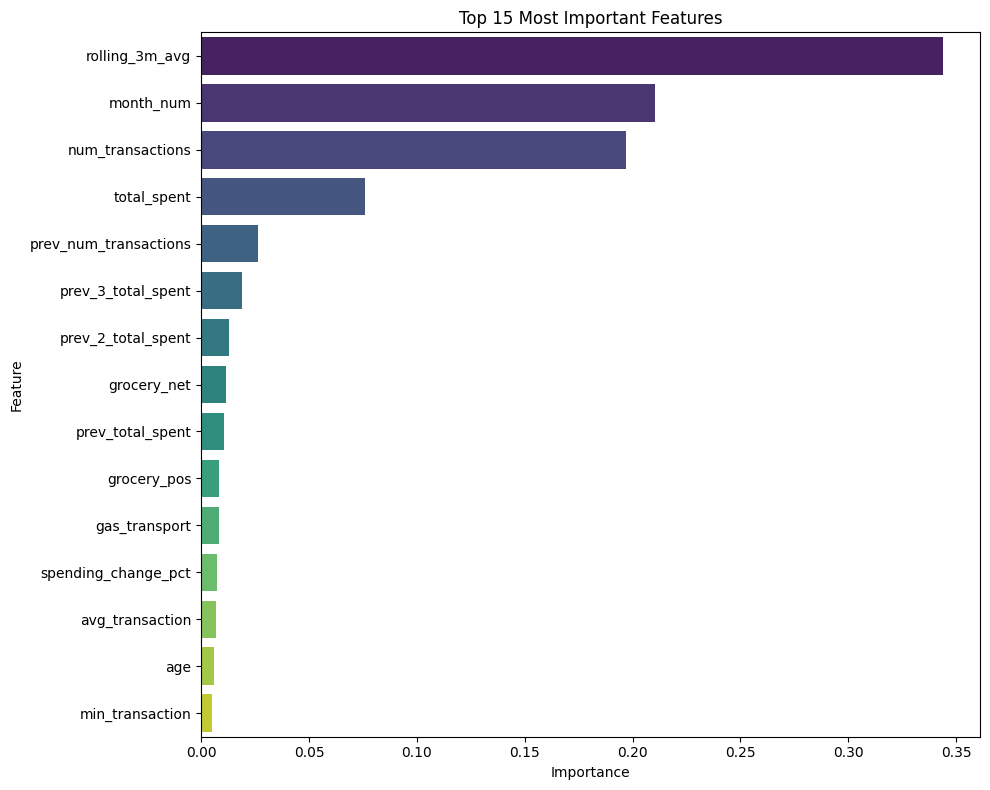


Top 10 Features:
              feature  importance
       rolling_3m_avg    0.343847
            month_num    0.210386
     num_transactions    0.197073
          total_spent    0.076172
prev_num_transactions    0.026334
   prev_3_total_spent    0.018782
   prev_2_total_spent    0.012774
          grocery_net    0.011387
     prev_total_spent    0.010690
          grocery_pos    0.008469


In [16]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': feature_cols,
    'importance': gb_model.feature_importances_
}).sort_values('importance', ascending=False)

# Plot top 15 features
plt.figure(figsize=(10, 8))
sns.barplot(data=feature_importance.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Most Important Features')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/gb_feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 Features:")
print(feature_importance.head(10).to_string(index=False))

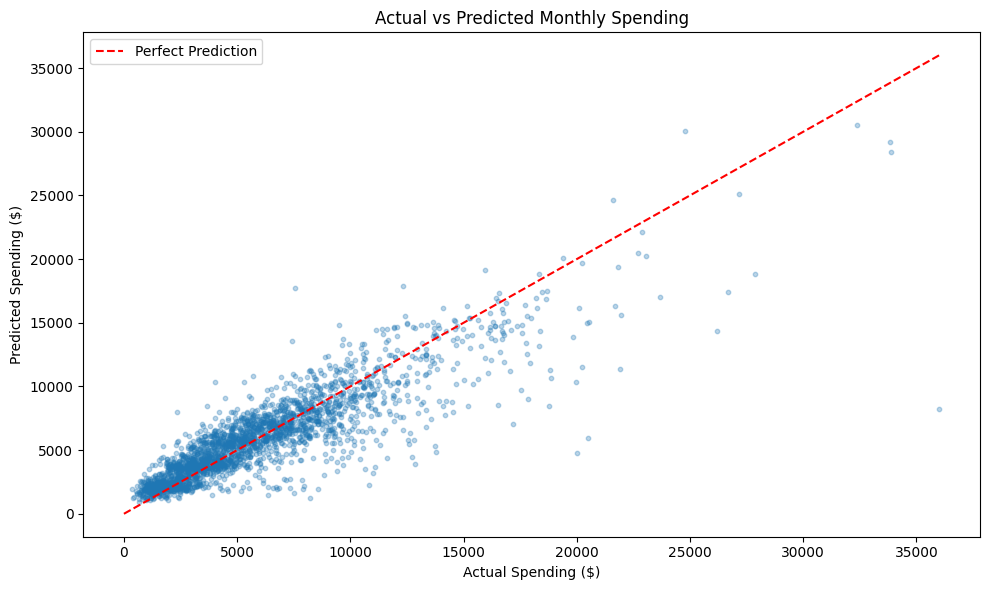

In [17]:
# Actual vs Predicted scatter plot
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred_test, alpha=0.3, s=10)
plt.plot([0, y_test.max()], [0, y_test.max()], 'r--', label='Perfect Prediction')
plt.xlabel('Actual Spending ($)')
plt.ylabel('Predicted Spending ($)')
plt.title('Actual vs Predicted Monthly Spending')
plt.legend()
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/archive/gb_actual_vs_predicted.png', dpi=150)
plt.show()

## Actual vs Predicted Analysis

The scatter plot shows how well our predictions match actual spending.

### Key Observations:
- **Points cluster around the red line** — indicates good predictions
- **Strong performance for $0 - $15,000** — where most users fall
- **More scatter at $20,000+** — fewer high spenders in training data, so less accurate


In [18]:
# Save the model
joblib.dump(gb_model, '/content/drive/MyDrive/archive/gradient_boosting_model.pkl')
print("Gradient Boosting model saved!")

# Save feature columns
joblib.dump(feature_cols, '/content/drive/MyDrive/archive/gb_feature_columns.pkl')
print("Feature columns saved!")

Gradient Boosting model saved!
Feature columns saved!
